In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

PROJECT_DIR = "/content/drive/MyDrive/A4-Generative-Models"

folders = [
    PROJECT_DIR,
    os.path.join(PROJECT_DIR, "saved"),
    os.path.join(PROJECT_DIR, "results"),
    os.path.join(PROJECT_DIR, "data"),
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folder created:")
print(PROJECT_DIR)

print("\nContents:")
for item in os.listdir(PROJECT_DIR):
    print("-", item)

Project folder created:
/content/drive/MyDrive/A4-Generative-Models

Contents:
- saved
- results
- data


In [4]:
run_py_path = os.path.join(PROJECT_DIR, "run.py")

starter_code = r'''
import argparse
import os
import random
import numpy as np
import torch


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def parse_args():
    parser = argparse.ArgumentParser(
        description="A4 Generative Models Training Script"
    )

    parser.add_argument(
        "--model",
        type=str,
        required=True,
        choices=["gan", "cyclegan", "ddpm"],
        help="Model to run"
    )

    parser.add_argument(
        "--dataset",
        type=str,
        choices=["mnist", "celeba"],
        help="Dataset to use"
    )

    parser.add_argument(
        "--epochs",
        type=int,
        default=20,
        help="Number of training epochs"
    )

    parser.add_argument(
        "--weights",
        type=str,
        default=None,
        help="Path to saved model weights"
    )

    parser.add_argument(
        "--test-image",
        type=str,
        default=None,
        help="Image used to test CycleGAN"
    )

    parser.add_argument(
        "--schedule",
        type=str,
        default="linear",
        choices=["linear", "cosine"],
        help="DDPM noise schedule"
    )

    parser.add_argument(
        "--n",
        type=int,
        default=64,
        help="Number of generated samples"
    )

    parser.add_argument(
        "--train",
        action="store_true",
        help="Train the selected model"
    )

    parser.add_argument(
        "--generate",
        action="store_true",
        help="Generate images using trained weights"
    )

    parser.add_argument(
        "--collapse",
        action="store_true",
        help="Train GAN with increased discriminator learning rate"
    )

    return parser.parse_args()


def main():
    args = parse_args()
    set_seed(42)

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    os.makedirs("saved", exist_ok=True)
    os.makedirs("results", exist_ok=True)

    print("=" * 60)
    print("A4 Generative Models")
    print("=" * 60)
    print(f"Model:      {args.model}")
    print(f"Dataset:    {args.dataset}")
    print(f"Epochs:     {args.epochs}")
    print(f"Device:     {device}")
    print(f"Train:      {args.train}")
    print(f"Generate:   {args.generate}")
    print(f"Schedule:   {args.schedule}")
    print(f"Collapse:   {args.collapse}")
    print("=" * 60)

    if args.model == "gan":
        print("GAN implementation will be added next.")

    elif args.model == "cyclegan":
        print("CycleGAN implementation will be added later.")

    elif args.model == "ddpm":
        print("DDPM implementation will be added later.")


if __name__ == "__main__":
    main()
'''

with open(run_py_path, "w", encoding="utf-8") as file:
    file.write(starter_code)

print("Created:", run_py_path)

Created: /content/drive/MyDrive/A4-Generative-Models/run.py


In [5]:
%cd /content/drive/MyDrive/A4-Generative-Models

/content/drive/MyDrive/A4-Generative-Models


In [6]:
!python run.py --model gan --dataset mnist --epochs 20 --train

A4 Generative Models
Model:      gan
Dataset:    mnist
Epochs:     20
Device:     cuda
Train:      True
Generate:   False
Schedule:   linear
Collapse:   False
GAN implementation will be added next.


In [7]:
!python run.py \
    --model ddpm \
    --dataset mnist \
    --epochs 20 \
    --schedule cosine \
    --train

A4 Generative Models
Model:      ddpm
Dataset:    mnist
Epochs:     20
Device:     cuda
Train:      True
Generate:   False
Schedule:   cosine
Collapse:   False
DDPM implementation will be added later.


In [8]:
run_py_path = "/content/drive/MyDrive/A4-Generative-Models/run.py"

gan_code = r'''
import argparse
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from tqdm import tqdm


# ============================================================
# General utilities
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device():
    return torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )


# ============================================================
# GAN model architecture
# ============================================================

class Generator(nn.Module):
    """
    Fully connected generator.

    Input:
        Random noise of shape [batch_size, z_dim]

    Output:
        Flattened MNIST images of shape [batch_size, 784]
    """

    def __init__(self, z_dim=100, img_dim=784):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """
    Fully connected discriminator.

    Input:
        Flattened image of shape [batch_size, 784]

    Output:
        Real/fake probability of shape [batch_size, 1]
    """

    def __init__(self, img_dim=784):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(img_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


# ============================================================
# Dataset
# ============================================================

def get_mnist_loader(batch_size=128):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])

    dataset = torchvision.datasets.MNIST(
        root="data",
        train=True,
        download=True,
        transform=transform
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    print(f"MNIST training images: {len(dataset)}")

    return loader


# ============================================================
# Save generated image grid
# ============================================================

def save_generated_grid(
    generator,
    noise,
    output_path,
    title=None
):
    generator.eval()

    with torch.no_grad():
        fake_images = generator(noise)
        fake_images = fake_images.view(-1, 1, 28, 28).cpu()

    grid = torchvision.utils.make_grid(
        fake_images,
        nrow=8,
        normalize=True
    )

    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")

    if title is not None:
        plt.title(title)

    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.close()

    generator.train()

    print(f"Saved generated samples to: {output_path}")


# ============================================================
# Save training curves
# ============================================================

def save_training_curves(
    generator_losses,
    discriminator_losses,
    epoch_times,
    output_path
):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(
        generator_losses,
        label="Generator Loss"
    )

    axes[0].plot(
        discriminator_losses,
        label="Discriminator Loss"
    )

    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("GAN Training Losses")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(
        epoch_times,
        marker="o"
    )

    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Seconds")
    axes[1].set_title(
        f"Epoch Time, average: {np.mean(epoch_times):.1f}s"
    )
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.close()

    print(f"Saved training curves to: {output_path}")


# ============================================================
# GAN training
# ============================================================

def train_gan(
    epochs,
    device,
    collapse=False,
    batch_size=128,
    z_dim=100
):
    os.makedirs("saved", exist_ok=True)
    os.makedirs("results", exist_ok=True)

    train_loader = get_mnist_loader(batch_size=batch_size)

    generator = Generator(z_dim=z_dim).to(device)
    discriminator = Discriminator().to(device)

    generator_lr = 2e-4

    # Exercise 1b:
    # Use 6e-4 to intentionally make the discriminator stronger.
    discriminator_lr = 6e-4 if collapse else 2e-4

    optimizer_g = torch.optim.Adam(
        generator.parameters(),
        lr=generator_lr,
        betas=(0.5, 0.999)
    )

    optimizer_d = torch.optim.Adam(
        discriminator.parameters(),
        lr=discriminator_lr,
        betas=(0.5, 0.999)
    )

    criterion = nn.BCELoss()

    fixed_noise = torch.randn(
        64,
        z_dim,
        device=device
    )

    generator_losses = []
    discriminator_losses = []
    epoch_times = []

    print()
    print("=" * 60)
    print("Starting GAN training")
    print(f"Generator learning rate:     {generator_lr}")
    print(f"Discriminator learning rate: {discriminator_lr}")
    print(f"Collapse experiment:         {collapse}")
    print("=" * 60)

    for epoch in range(epochs):
        start_time = time.time()

        epoch_generator_losses = []
        epoch_discriminator_losses = []

        progress_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch + 1}/{epochs}"
        )

        for real_images, _ in progress_bar:
            current_batch_size = real_images.size(0)

            real_images = real_images.view(
                current_batch_size,
                -1
            ).to(device)

            real_labels = torch.ones(
                current_batch_size,
                1,
                device=device
            )

            fake_labels = torch.zeros(
                current_batch_size,
                1,
                device=device
            )

            # ----------------------------------------------
            # Train discriminator
            # ----------------------------------------------

            noise = torch.randn(
                current_batch_size,
                z_dim,
                device=device
            )

            fake_images = generator(noise).detach()

            real_predictions = discriminator(real_images)
            fake_predictions = discriminator(fake_images)

            real_loss = criterion(
                real_predictions,
                real_labels
            )

            fake_loss = criterion(
                fake_predictions,
                fake_labels
            )

            discriminator_loss = real_loss + fake_loss

            optimizer_d.zero_grad()
            discriminator_loss.backward()
            optimizer_d.step()

            # ----------------------------------------------
            # Train generator
            # ----------------------------------------------

            noise = torch.randn(
                current_batch_size,
                z_dim,
                device=device
            )

            generated_images = generator(noise)
            predictions = discriminator(generated_images)

            generator_loss = criterion(
                predictions,
                real_labels
            )

            optimizer_g.zero_grad()
            generator_loss.backward()
            optimizer_g.step()

            epoch_generator_losses.append(
                generator_loss.item()
            )

            epoch_discriminator_losses.append(
                discriminator_loss.item()
            )

            progress_bar.set_postfix({
                "G": f"{generator_loss.item():.3f}",
                "D": f"{discriminator_loss.item():.3f}"
            })

        epoch_time = time.time() - start_time

        average_generator_loss = np.mean(
            epoch_generator_losses
        )

        average_discriminator_loss = np.mean(
            epoch_discriminator_losses
        )

        generator_losses.append(average_generator_loss)
        discriminator_losses.append(average_discriminator_loss)
        epoch_times.append(epoch_time)

        print(
            f"Epoch {epoch + 1:02d} | "
            f"G loss: {average_generator_loss:.4f} | "
            f"D loss: {average_discriminator_loss:.4f} | "
            f"Time: {epoch_time:.1f}s"
        )

        # Save a sample grid every five epochs.
        if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            experiment_name = (
                "collapse" if collapse else "normal"
            )

            sample_path = (
                f"results/gan_{experiment_name}_"
                f"epoch_{epoch + 1}.png"
            )

            save_generated_grid(
                generator,
                fixed_noise,
                sample_path,
                title=f"GAN samples — epoch {epoch + 1}"
            )

    # ------------------------------------------------------
    # Save trained model
    # ------------------------------------------------------

    if collapse:
        weights_path = "saved/gan_mnist_collapse.pt"
        final_grid_path = "results/gan_collapse_samples.png"
        curves_path = "results/gan_collapse_training.png"
    else:
        weights_path = "saved/gan_mnist.pt"
        final_grid_path = "results/gan_samples.png"
        curves_path = "results/gan_training.png"

    checkpoint = {
        "generator_state_dict": generator.state_dict(),
        "discriminator_state_dict": discriminator.state_dict(),
        "z_dim": z_dim,
        "epochs": epochs,
        "generator_lr": generator_lr,
        "discriminator_lr": discriminator_lr,
        "collapse": collapse,
        "generator_losses": generator_losses,
        "discriminator_losses": discriminator_losses,
        "epoch_times": epoch_times
    }

    torch.save(checkpoint, weights_path)

    save_generated_grid(
        generator,
        fixed_noise,
        final_grid_path,
        title="Final GAN Generated Samples"
    )

    save_training_curves(
        generator_losses,
        discriminator_losses,
        epoch_times,
        curves_path
    )

    print()
    print("GAN training completed.")
    print(f"Weights saved to: {weights_path}")

    return generator


# ============================================================
# Generate from saved GAN
# ============================================================

def generate_gan_samples(
    weights_path,
    number_of_samples,
    device
):
    checkpoint = torch.load(
        weights_path,
        map_location=device
    )

    z_dim = checkpoint.get("z_dim", 100)

    generator = Generator(z_dim=z_dim).to(device)

    generator.load_state_dict(
        checkpoint["generator_state_dict"]
    )

    generator.eval()

    noise = torch.randn(
        number_of_samples,
        z_dim,
        device=device
    )

    output_path = "results/gan_generated.png"

    save_generated_grid(
        generator,
        noise[:64],
        output_path,
        title="Generated MNIST Samples"
    )


# ============================================================
# Command-line arguments
# ============================================================

def parse_args():
    parser = argparse.ArgumentParser(
        description="A4 Generative Models"
    )

    parser.add_argument(
        "--model",
        type=str,
        required=True,
        choices=["gan", "cyclegan", "ddpm"]
    )

    parser.add_argument(
        "--dataset",
        type=str,
        choices=["mnist", "celeba"],
        default=None
    )

    parser.add_argument(
        "--epochs",
        type=int,
        default=20
    )

    parser.add_argument(
        "--weights",
        type=str,
        default=None
    )

    parser.add_argument(
        "--test-image",
        type=str,
        default=None
    )

    parser.add_argument(
        "--schedule",
        type=str,
        default="linear",
        choices=["linear", "cosine"]
    )

    parser.add_argument(
        "--n",
        type=int,
        default=64
    )

    parser.add_argument(
        "--train",
        action="store_true"
    )

    parser.add_argument(
        "--generate",
        action="store_true"
    )

    parser.add_argument(
        "--collapse",
        action="store_true"
    )

    return parser.parse_args()


# ============================================================
# Main
# ============================================================

def main():
    args = parse_args()

    set_seed(42)

    device = get_device()

    print("=" * 60)
    print("A4 Generative Models")
    print("=" * 60)
    print(f"Model:    {args.model}")
    print(f"Dataset:  {args.dataset}")
    print(f"Epochs:   {args.epochs}")
    print(f"Device:   {device}")
    print("=" * 60)

    if args.model == "gan":
        if args.train:
            train_gan(
                epochs=args.epochs,
                device=device,
                collapse=args.collapse
            )

        elif args.generate:
            if args.weights is None:
                raise ValueError(
                    "--weights is required when using --generate"
                )

            generate_gan_samples(
                weights_path=args.weights,
                number_of_samples=args.n,
                device=device
            )

        else:
            print(
                "Use either --train or --generate for the GAN."
            )

    elif args.model == "cyclegan":
        print("CycleGAN will be implemented after Exercise 1.")

    elif args.model == "ddpm":
        print("DDPM will be implemented later.")


if __name__ == "__main__":
    main()
'''

with open(run_py_path, "w", encoding="utf-8") as file:
    file.write(gan_code)

print("Updated:", run_py_path)

Updated: /content/drive/MyDrive/A4-Generative-Models/run.py


In [12]:
%cd /content/drive/MyDrive/A4-Generative-Models

/content/drive/MyDrive/A4-Generative-Models


In [13]:
!python run.py \
    --model gan \
    --dataset mnist \
    --epochs 20 \
    --train

A4 Generative Models
Model:    gan
Dataset:  mnist
Epochs:   20
Device:   cuda
MNIST training images: 60000

Starting GAN training
Generator learning rate:     0.0002
Discriminator learning rate: 0.0002
Collapse experiment:         False
Epoch 1/20: 100% 469/469 [00:06<00:00, 68.03it/s, G=2.611, D=0.415]
Epoch 01 | G loss: 2.0228 | D loss: 0.8027 | Time: 6.9s
Epoch 2/20: 100% 469/469 [00:07<00:00, 64.64it/s, G=1.229, D=0.795]
Epoch 02 | G loss: 3.4391 | D loss: 0.5348 | Time: 7.3s
Epoch 3/20: 100% 469/469 [00:06<00:00, 69.33it/s, G=6.672, D=0.385]
Epoch 03 | G loss: 3.6274 | D loss: 0.4434 | Time: 6.8s
Epoch 4/20: 100% 469/469 [00:06<00:00, 69.35it/s, G=3.732, D=0.449]
Epoch 04 | G loss: 3.3718 | D loss: 0.4377 | Time: 6.8s
Epoch 5/20: 100% 469/469 [00:06<00:00, 67.75it/s, G=3.995, D=0.543]
Epoch 05 | G loss: 2.5598 | D loss: 0.5432 | Time: 6.9s
Saved generated samples to: results/gan_normal_epoch_5.png
Epoch 6/20: 100% 469/469 [00:06<00:00, 71.97it/s, G=2.004, D=0.583]
Epoch 06 | G lo

In [14]:
!python run.py \
    --model gan \
    --dataset mnist \
    --epochs 20 \
    --train \
    --collapse

A4 Generative Models
Model:    gan
Dataset:  mnist
Epochs:   20
Device:   cuda
MNIST training images: 60000

Starting GAN training
Generator learning rate:     0.0002
Discriminator learning rate: 0.0006
Collapse experiment:         True
Epoch 1/20: 100% 469/469 [00:07<00:00, 62.51it/s, G=3.288, D=0.466]
Epoch 01 | G loss: 1.8510 | D loss: 0.7862 | Time: 7.5s
Epoch 2/20: 100% 469/469 [00:06<00:00, 71.30it/s, G=0.544, D=1.203]
Epoch 02 | G loss: 2.4344 | D loss: 0.6608 | Time: 6.6s
Epoch 3/20: 100% 469/469 [00:07<00:00, 64.91it/s, G=3.528, D=0.748]
Epoch 03 | G loss: 2.4096 | D loss: 0.5935 | Time: 7.2s
Epoch 4/20: 100% 469/469 [00:06<00:00, 69.65it/s, G=2.050, D=0.571]
Epoch 04 | G loss: 2.2753 | D loss: 0.5988 | Time: 6.7s
Epoch 5/20: 100% 469/469 [00:07<00:00, 66.56it/s, G=2.599, D=0.783]
Epoch 05 | G loss: 1.9915 | D loss: 0.7069 | Time: 7.0s
Saved generated samples to: results/gan_collapse_epoch_5.png
Epoch 6/20: 100% 469/469 [00:07<00:00, 65.96it/s, G=1.988, D=0.767]
Epoch 06 | G l

Normal GAN


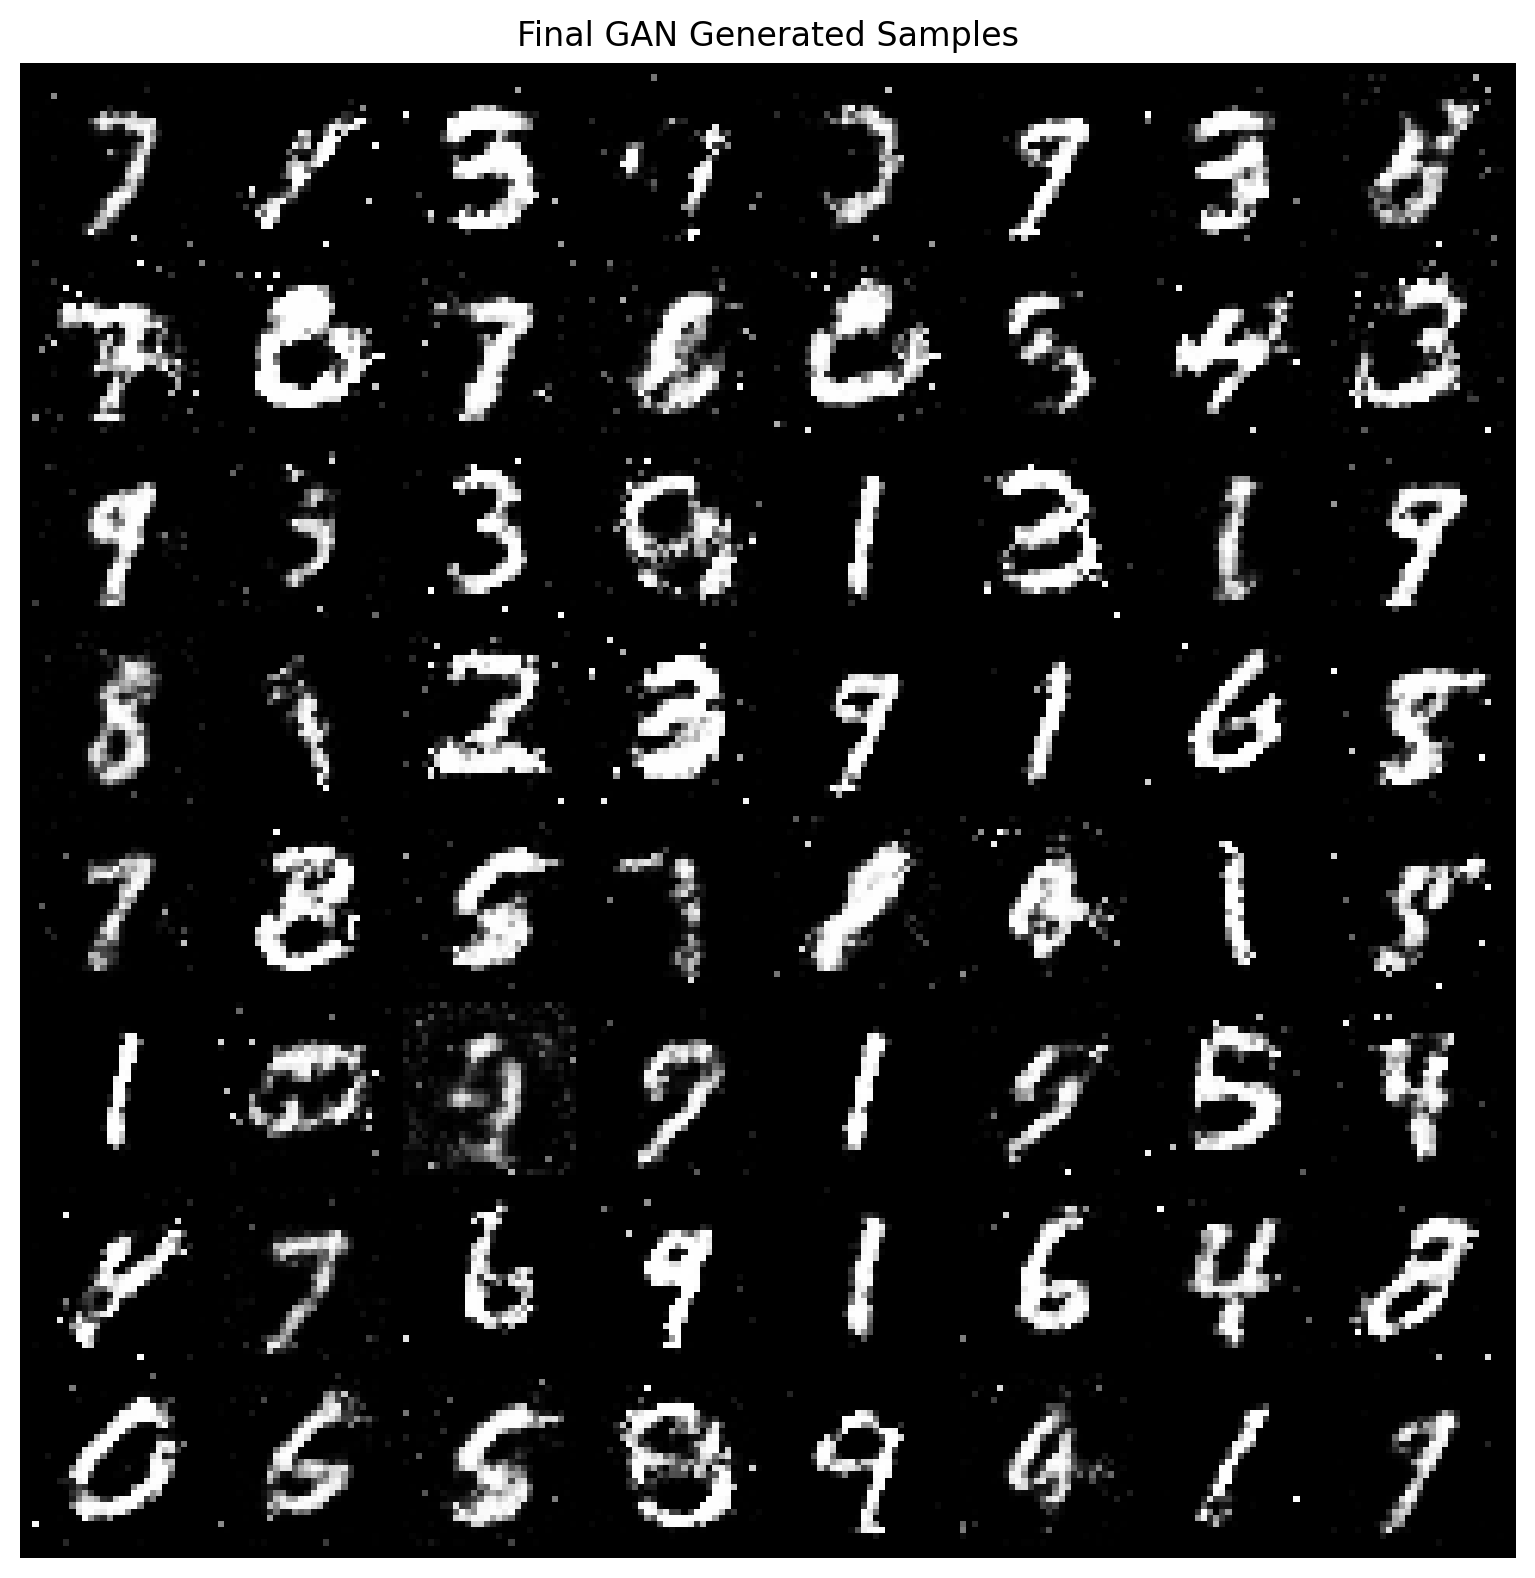

Mode-collapse experiment


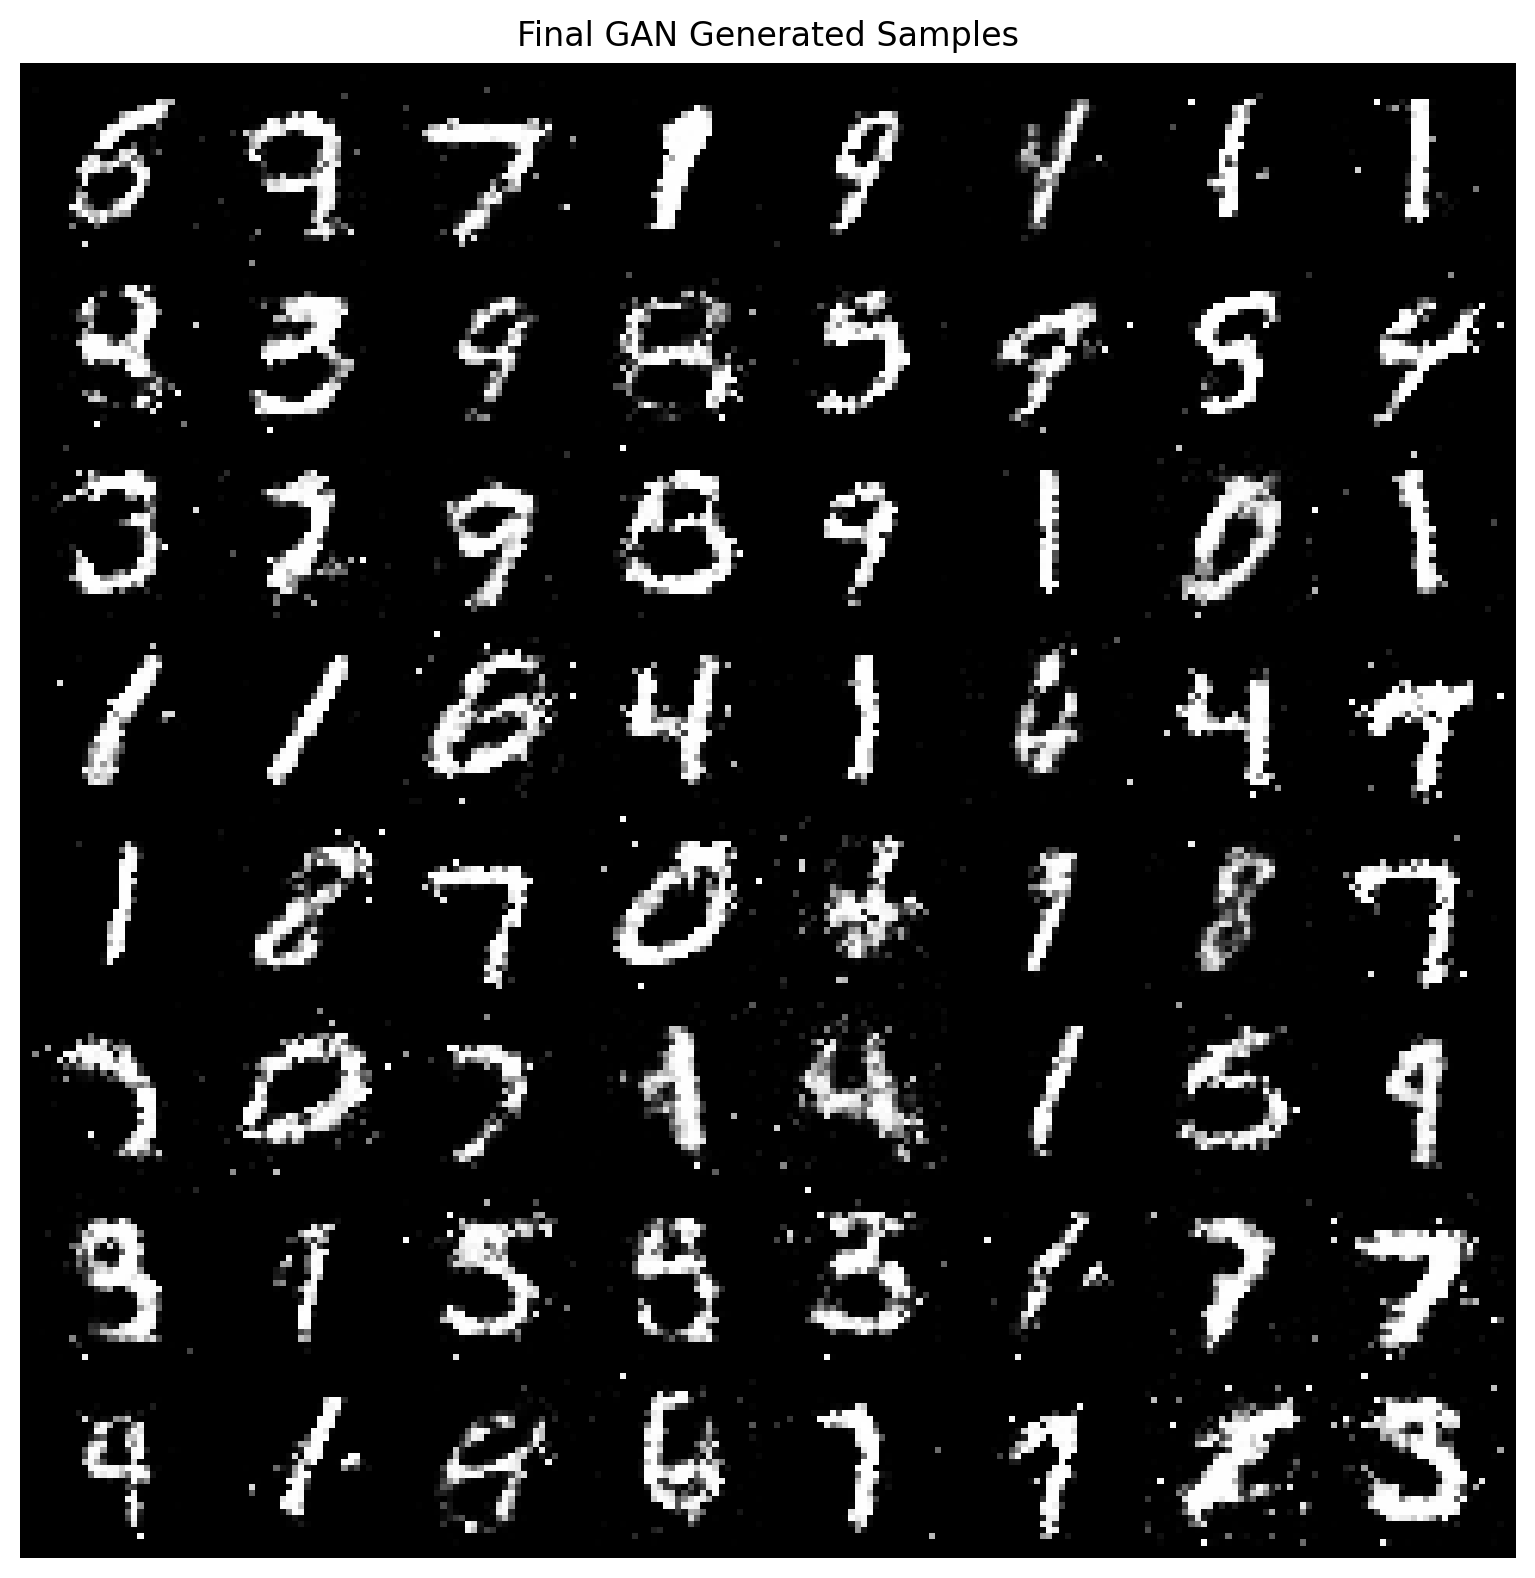

In [15]:
from IPython.display import display, Image

print("Normal GAN")
display(Image(filename="results/gan_samples.png"))

print("Mode-collapse experiment")
display(Image(filename="results/gan_collapse_samples.png"))

Normal GAN training


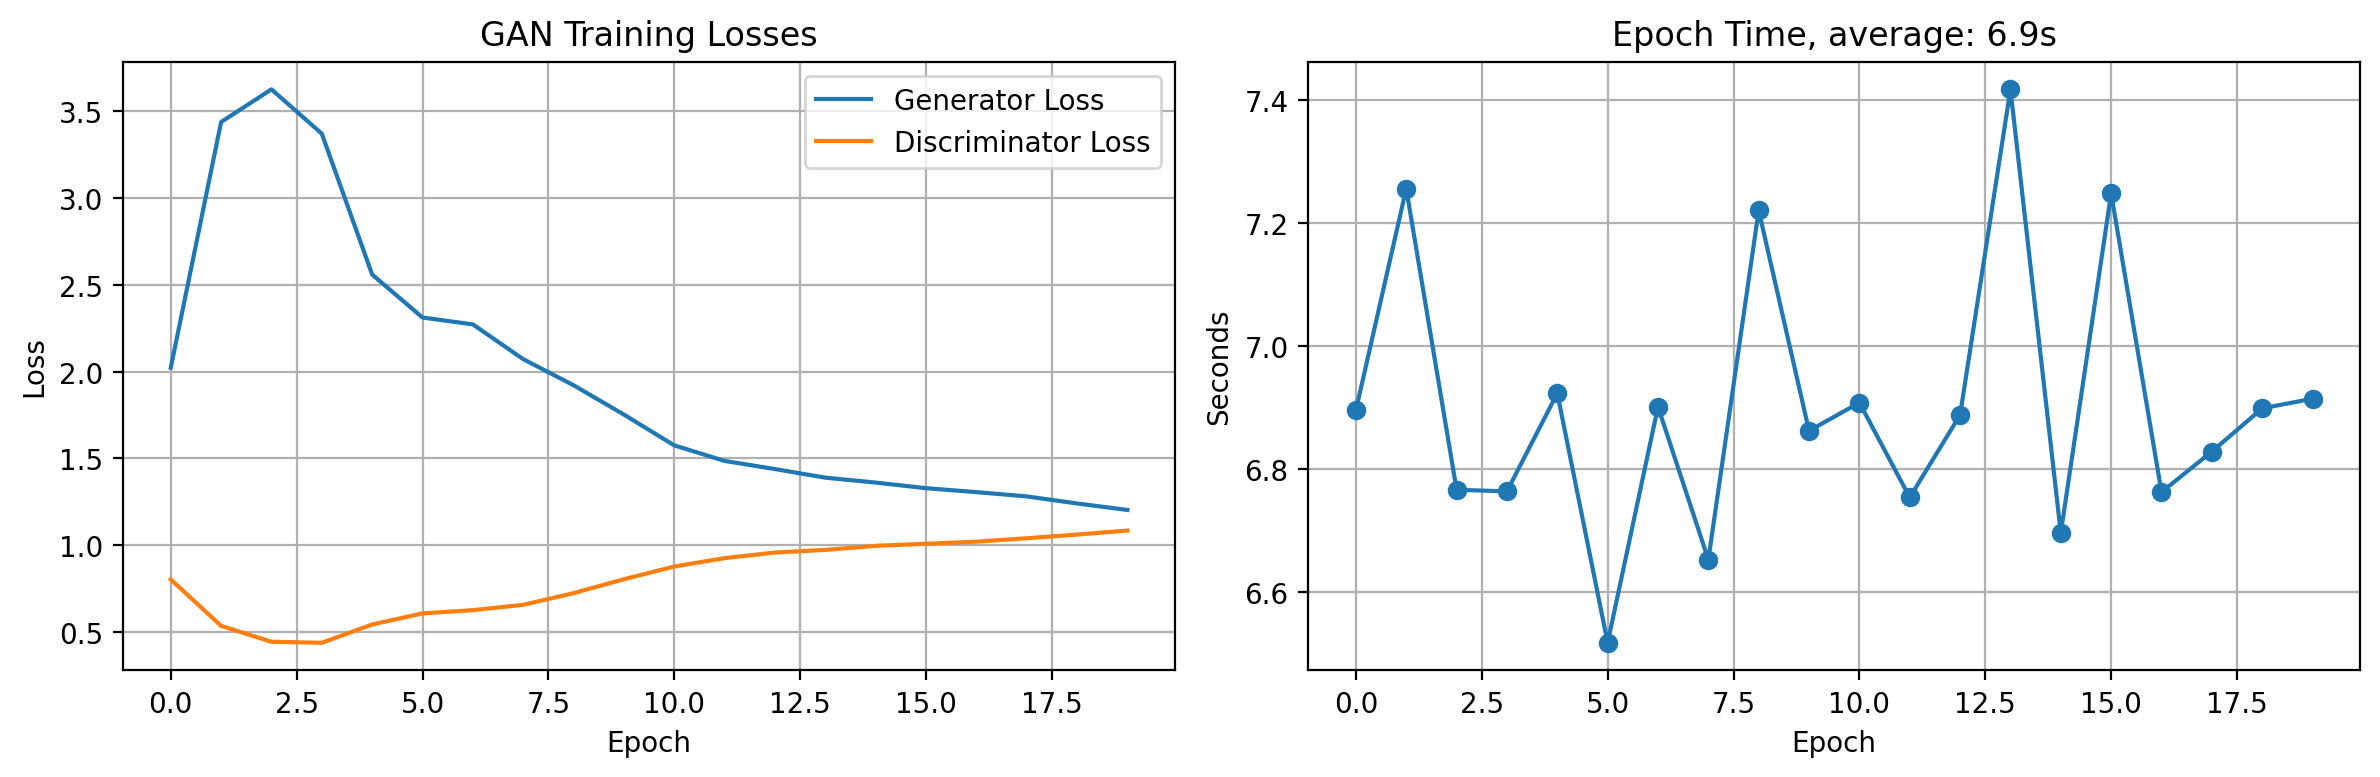

Collapse GAN training


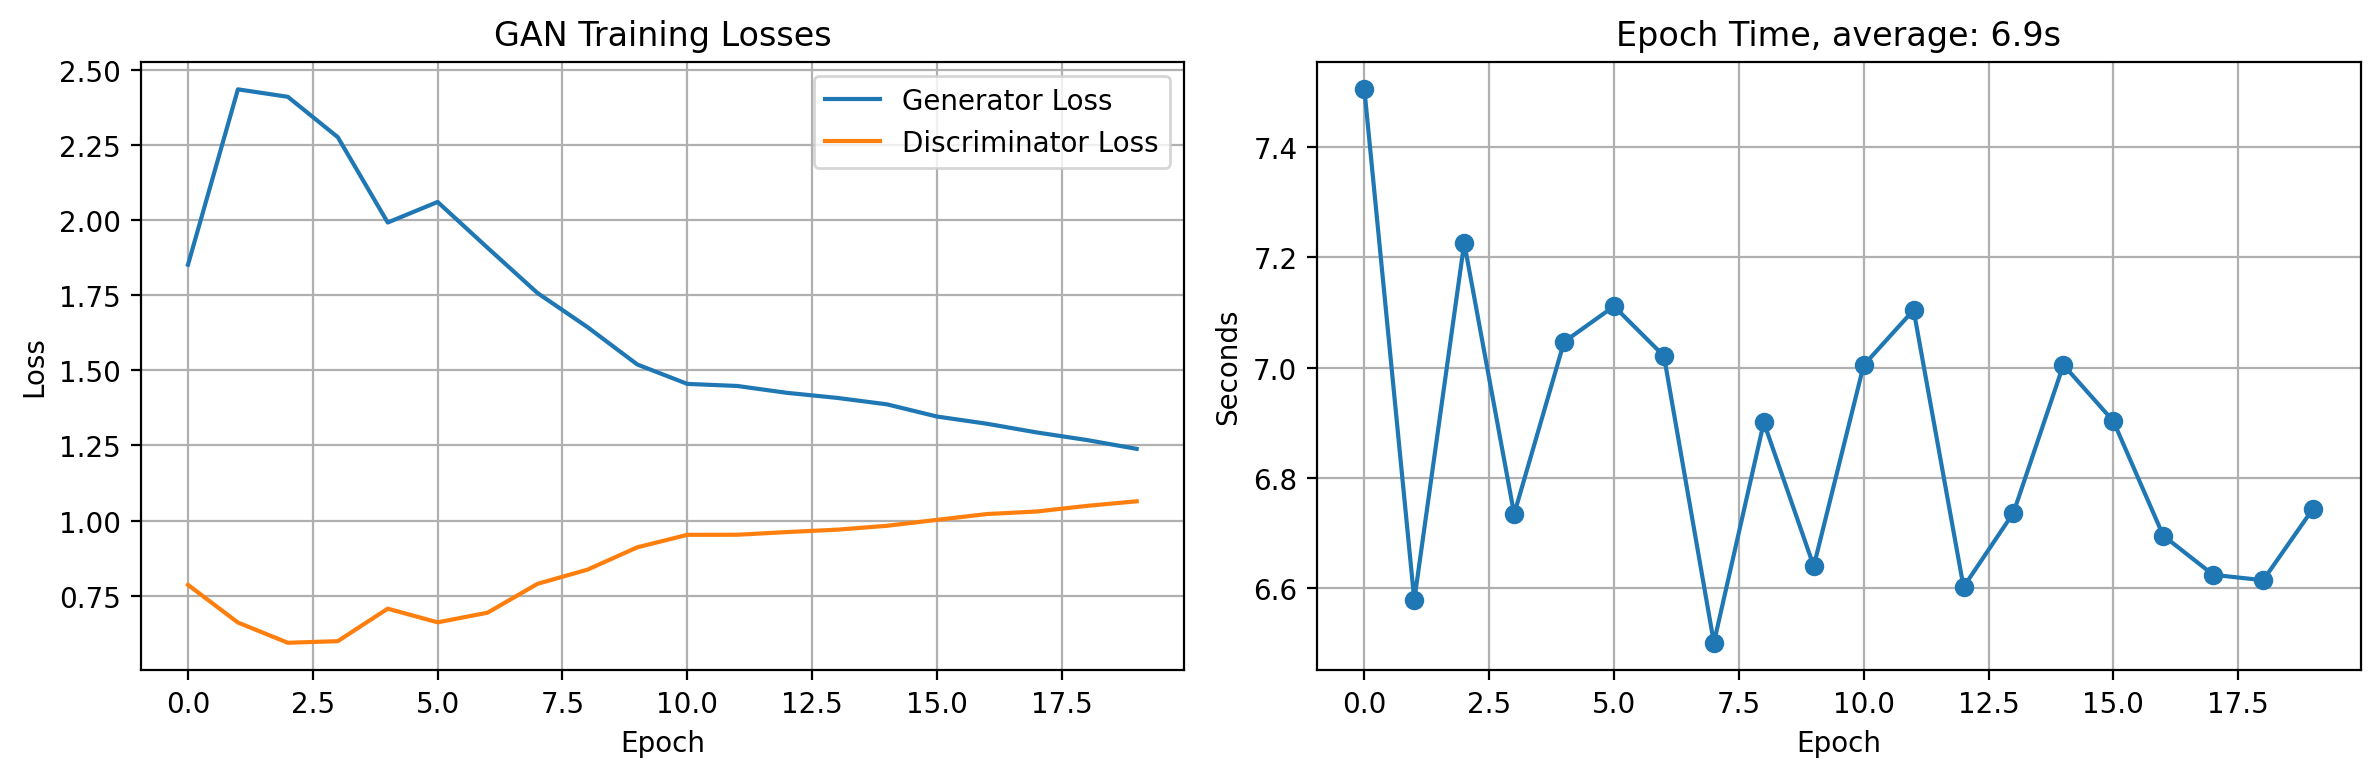

In [16]:
print("Normal GAN training")
display(Image(filename="results/gan_training.png"))

print("Collapse GAN training")
display(Image(filename="results/gan_collapse_training.png"))

In [17]:
import os

PROJECT_DIR = "/content/drive/MyDrive/A4-Generative-Models"
evaluation_path = os.path.join(PROJECT_DIR, "evaluate_gan.py")

evaluation_code = r'''
import argparse
import csv
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from tqdm import tqdm

# Import the Generator architecture from run.py
from run import Generator


# ============================================================
# Reproducibility
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ============================================================
# MNIST classifier
# ============================================================

class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


# ============================================================
# MNIST DataLoaders
# ============================================================

def get_mnist_loaders(batch_size=128):
    # Match the GAN output range: [-1, 1]
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])

    train_dataset = torchvision.datasets.MNIST(
        root="data",
        train=True,
        download=True,
        transform=transform
    )

    test_dataset = torchvision.datasets.MNIST(
        root="data",
        train=False,
        download=True,
        transform=transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, test_loader


# ============================================================
# Train classifier
# ============================================================

def train_classifier(
    classifier,
    train_loader,
    test_loader,
    device,
    epochs=3
):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        classifier.parameters(),
        lr=1e-3
    )

    print("\nTraining MNIST classifier...")

    for epoch in range(epochs):
        classifier.train()

        running_loss = 0.0
        correct = 0
        total = 0

        progress = tqdm(
            train_loader,
            desc=f"Classifier epoch {epoch + 1}/{epochs}"
        )

        for images, labels in progress:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = classifier(images)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            predictions = logits.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

            progress.set_postfix({
                "loss": f"{loss.item():.4f}",
                "accuracy": f"{100 * correct / total:.2f}%"
            })

        test_accuracy = evaluate_classifier(
            classifier,
            test_loader,
            device
        )

        print(
            f"Epoch {epoch + 1}: "
            f"training accuracy={100 * correct / total:.2f}% | "
            f"test accuracy={test_accuracy:.2f}%"
        )

    return classifier


# ============================================================
# Evaluate classifier
# ============================================================

def evaluate_classifier(classifier, data_loader, device):
    classifier.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = classifier(images)
            predictions = logits.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    return 100 * correct / total


# ============================================================
# Load or train classifier
# ============================================================

def load_or_train_classifier(device, classifier_path):
    classifier = MNISTClassifier().to(device)

    if os.path.exists(classifier_path):
        print(f"Loading classifier: {classifier_path}")

        state_dict = torch.load(
            classifier_path,
            map_location=device
        )

        classifier.load_state_dict(state_dict)

        _, test_loader = get_mnist_loaders()

        test_accuracy = evaluate_classifier(
            classifier,
            test_loader,
            device
        )

        print(
            f"Classifier test accuracy: "
            f"{test_accuracy:.2f}%"
        )

        return classifier

    train_loader, test_loader = get_mnist_loaders()

    classifier = train_classifier(
        classifier=classifier,
        train_loader=train_loader,
        test_loader=test_loader,
        device=device,
        epochs=3
    )

    torch.save(
        classifier.state_dict(),
        classifier_path
    )

    print(f"Classifier saved to: {classifier_path}")

    return classifier


# ============================================================
# Load a trained GAN
# ============================================================

def load_generator(weights_path, device):
    checkpoint = torch.load(
        weights_path,
        map_location=device
    )

    z_dim = checkpoint.get("z_dim", 100)

    generator = Generator(
        z_dim=z_dim
    ).to(device)

    generator.load_state_dict(
        checkpoint["generator_state_dict"]
    )

    generator.eval()

    return generator, z_dim


# ============================================================
# Generate and classify GAN samples
# ============================================================

def classify_generated_samples(
    generator,
    classifier,
    z_dim,
    number_of_samples,
    device,
    batch_size=100
):
    counts = torch.zeros(
        10,
        dtype=torch.long
    )

    all_images = []
    all_predictions = []
    all_confidences = []

    generator.eval()
    classifier.eval()

    generated_so_far = 0

    with torch.no_grad():
        while generated_so_far < number_of_samples:
            current_batch_size = min(
                batch_size,
                number_of_samples - generated_so_far
            )

            noise = torch.randn(
                current_batch_size,
                z_dim,
                device=device
            )

            generated = generator(noise)

            generated = generated.view(
                current_batch_size,
                1,
                28,
                28
            )

            logits = classifier(generated)
            probabilities = torch.softmax(logits, dim=1)

            confidence, predictions = probabilities.max(dim=1)

            batch_counts = torch.bincount(
                predictions.cpu(),
                minlength=10
            )

            counts += batch_counts

            all_images.append(generated.cpu())
            all_predictions.append(predictions.cpu())
            all_confidences.append(confidence.cpu())

            generated_so_far += current_batch_size

    images = torch.cat(all_images, dim=0)
    predictions = torch.cat(all_predictions, dim=0)
    confidences = torch.cat(all_confidences, dim=0)

    return counts.numpy(), images, predictions, confidences


# ============================================================
# Print count table
# ============================================================

def print_count_table(name, counts):
    print()
    print("=" * 74)
    print(name)
    print("=" * 74)

    digit_header = "Digit | " + " | ".join(
        str(digit) for digit in range(10)
    )

    separator = "-" * len(digit_header)

    count_row = "Count | " + " | ".join(
        str(int(count)) for count in counts
    )

    print(digit_header)
    print(separator)
    print(count_row)
    print(f"Total: {counts.sum()}")

    vanished_digits = np.where(counts == 0)[0].tolist()

    if vanished_digits:
        print(f"Vanished digits: {vanished_digits}")
    else:
        print("No digit has a count of exactly zero.")


# ============================================================
# Save sample grid with predicted labels
# ============================================================

def save_labeled_grid(
    images,
    predictions,
    confidences,
    output_path,
    title
):
    number_to_show = min(64, len(images))

    fig, axes = plt.subplots(
        8,
        8,
        figsize=(10, 11)
    )

    for index, axis in enumerate(axes.flat):
        if index < number_to_show:
            image = images[index].squeeze().numpy()

            axis.imshow(
                image,
                cmap="gray",
                vmin=-1,
                vmax=1
            )

            axis.set_title(
                f"{predictions[index].item()} "
                f"({confidences[index].item():.2f})",
                fontsize=7
            )

        axis.axis("off")

    fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )
    plt.close()

    print(f"Saved labeled samples to: {output_path}")


# ============================================================
# Plot separate distribution
# ============================================================

def save_distribution_plot(
    counts,
    output_path,
    title
):
    digits = np.arange(10)

    plt.figure(figsize=(9, 5))
    bars = plt.bar(digits, counts)

    plt.axhline(
        y=100,
        linestyle="--",
        label="Perfectly even count = 100"
    )

    for bar, count in zip(bars, counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            str(int(count)),
            ha="center",
            fontsize=9
        )

    plt.xticks(digits)
    plt.xlabel("Predicted digit")
    plt.ylabel("Count out of 1,000")
    plt.title(title)
    plt.ylim(0, max(counts.max() + 60, 150))
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )
    plt.close()

    print(f"Saved distribution plot to: {output_path}")


# ============================================================
# Plot normal versus collapse
# ============================================================

def save_comparison_plot(
    normal_counts,
    collapse_counts,
    output_path
):
    digits = np.arange(10)
    width = 0.38

    plt.figure(figsize=(11, 6))

    plt.bar(
        digits - width / 2,
        normal_counts,
        width,
        label="Normal GAN"
    )

    plt.bar(
        digits + width / 2,
        collapse_counts,
        width,
        label="High discriminator LR"
    )

    plt.axhline(
        y=100,
        linestyle="--",
        label="Perfectly even count = 100"
    )

    plt.xticks(digits)
    plt.xlabel("Predicted digit")
    plt.ylabel("Count out of 1,000")
    plt.title("GAN Digit Distribution: Normal vs Mode-Collapse Experiment")
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )
    plt.close()

    print(f"Saved comparison plot to: {output_path}")


# ============================================================
# Distribution metrics
# ============================================================

def calculate_distribution_metrics(counts):
    probabilities = counts / counts.sum()

    entropy = -np.sum(
        probabilities[probabilities > 0]
        * np.log(probabilities[probabilities > 0])
    )

    normalized_entropy = entropy / np.log(10)

    expected_count = counts.sum() / 10

    mean_absolute_deviation = np.mean(
        np.abs(counts - expected_count)
    )

    covered_digits = int(np.sum(counts > 0))

    return {
        "covered_digits": covered_digits,
        "normalized_entropy": normalized_entropy,
        "mean_absolute_deviation": mean_absolute_deviation,
        "minimum_count": int(counts.min()),
        "maximum_count": int(counts.max())
    }


# ============================================================
# Save results as CSV
# ============================================================

def save_results_csv(
    normal_counts,
    collapse_counts,
    output_path
):
    with open(
        output_path,
        "w",
        newline="",
        encoding="utf-8"
    ) as csv_file:
        writer = csv.writer(csv_file)

        writer.writerow([
            "Digit",
            "Normal GAN count",
            "Collapse GAN count"
        ])

        for digit in range(10):
            writer.writerow([
                digit,
                int(normal_counts[digit]),
                int(collapse_counts[digit])
            ])

        writer.writerow([
            "Total",
            int(normal_counts.sum()),
            int(collapse_counts.sum())
        ])

    print(f"Saved count table to: {output_path}")


# ============================================================
# Main evaluation
# ============================================================

def main(args):
    set_seed(args.seed)

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    os.makedirs("saved", exist_ok=True)
    os.makedirs("results", exist_ok=True)

    print(f"Device: {device}")

    classifier_path = "saved/mnist_classifier.pt"

    classifier = load_or_train_classifier(
        device=device,
        classifier_path=classifier_path
    )

    print("\nLoading normal GAN...")
    normal_generator, normal_z_dim = load_generator(
        args.normal_weights,
        device
    )

    print("Generating and classifying normal GAN samples...")

    (
        normal_counts,
        normal_images,
        normal_predictions,
        normal_confidences
    ) = classify_generated_samples(
        generator=normal_generator,
        classifier=classifier,
        z_dim=normal_z_dim,
        number_of_samples=args.n,
        device=device
    )

    print("\nLoading collapse GAN...")
    collapse_generator, collapse_z_dim = load_generator(
        args.collapse_weights,
        device
    )

    print("Generating and classifying collapse GAN samples...")

    (
        collapse_counts,
        collapse_images,
        collapse_predictions,
        collapse_confidences
    ) = classify_generated_samples(
        generator=collapse_generator,
        classifier=classifier,
        z_dim=collapse_z_dim,
        number_of_samples=args.n,
        device=device
    )

    print_count_table(
        "Normal GAN distribution",
        normal_counts
    )

    print_count_table(
        "Mode-collapse experiment distribution",
        collapse_counts
    )

    normal_metrics = calculate_distribution_metrics(
        normal_counts
    )

    collapse_metrics = calculate_distribution_metrics(
        collapse_counts
    )

    print("\nNormal GAN metrics:")
    for key, value in normal_metrics.items():
        print(f"  {key}: {value}")

    print("\nCollapse GAN metrics:")
    for key, value in collapse_metrics.items():
        print(f"  {key}: {value}")

    save_distribution_plot(
        counts=normal_counts,
        output_path="results/gan_distribution.png",
        title="Normal GAN Digit Distribution"
    )

    save_distribution_plot(
        counts=collapse_counts,
        output_path="results/gan_collapse_distribution.png",
        title="GAN Distribution with Discriminator LR = 6e-4"
    )

    save_comparison_plot(
        normal_counts=normal_counts,
        collapse_counts=collapse_counts,
        output_path="results/gan_distribution_comparison.png"
    )

    save_labeled_grid(
        images=normal_images,
        predictions=normal_predictions,
        confidences=normal_confidences,
        output_path="results/gan_classified_samples.png",
        title="Normal GAN Samples with Classifier Predictions"
    )

    save_labeled_grid(
        images=collapse_images,
        predictions=collapse_predictions,
        confidences=collapse_confidences,
        output_path="results/gan_collapse_classified_samples.png",
        title="Collapse GAN Samples with Classifier Predictions"
    )

    save_results_csv(
        normal_counts=normal_counts,
        collapse_counts=collapse_counts,
        output_path="results/gan_digit_counts.csv"
    )

    print("\nEvaluation completed.")


if __name__ == "__main__":
    parser = argparse.ArgumentParser(
        description="Evaluate GAN mode collapse"
    )

    parser.add_argument(
        "--normal-weights",
        type=str,
        default="saved/gan_mnist.pt"
    )

    parser.add_argument(
        "--collapse-weights",
        type=str,
        default="saved/gan_mnist_collapse.pt"
    )

    parser.add_argument(
        "--n",
        type=int,
        default=1000
    )

    parser.add_argument(
        "--seed",
        type=int,
        default=42
    )

    args = parser.parse_args()
    main(args)
'''

with open(evaluation_path, "w", encoding="utf-8") as file:
    file.write(evaluation_code)

print("Created:", evaluation_path)

Created: /content/drive/MyDrive/A4-Generative-Models/evaluate_gan.py


In [23]:
!python evaluate_gan.py \
    --normal-weights saved/gan_mnist.pt \
    --collapse-weights saved/gan_mnist_collapse.pt \
    --n 1000

Device: cuda
Loading classifier: saved/mnist_classifier.pt
Classifier test accuracy: 98.91%

Loading normal GAN...
Generating and classifying normal GAN samples...

Loading collapse GAN...
Generating and classifying collapse GAN samples...

Normal GAN distribution
Digit | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9
---------------------------------------------
Count | 38 | 211 | 63 | 154 | 46 | 77 | 74 | 88 | 74 | 175
Total: 1000
No digit has a count of exactly zero.

Mode-collapse experiment distribution
Digit | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9
---------------------------------------------
Count | 83 | 187 | 80 | 93 | 84 | 58 | 45 | 164 | 89 | 117
Total: 1000
No digit has a count of exactly zero.

Normal GAN metrics:
  covered_digits: 10
  normalized_entropy: 0.9372689053512226
  mean_absolute_deviation: 48.0
  minimum_count: 38
  maximum_count: 211

Collapse GAN metrics:
  covered_digits: 10
  normalized_entropy: 0.9635453304643294
  mean_absolute_deviation: 33.6
  minimum_count: 45
 

In [24]:
import os

CELEBA_ROOT = "/content/data/celeba"

for root, directories, files in os.walk(CELEBA_ROOT):
    level = root.replace(CELEBA_ROOT, "").count(os.sep)
    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    for filename in files[:5]:
        print(f"{indent}  {filename}")

    if level >= 2:
        directories[:] = []

In [29]:
import os

possible_image_paths = [
    "/content/data/celeba/img_align_celeba",
    "/content/data/celeba/celeba/img_align_celeba",
    "/content/data/celeba/Img/img_align_celeba",
]

possible_attr_paths = [
    "/content/data/celeba/list_attr_celeba.txt",
    "/content/data/celeba/list_attr_celeba.txt",
    "/content/data/celeba/Anno/list_attr_celeba.txt",
]

print("Image folders:")
for path in possible_image_paths:
    print(os.path.exists(path), path)

print("\nAttribute files:")
for path in possible_attr_paths:
    print(os.path.exists(path), path)

False /content/drive/MyDrive/data/celeba/img_align_celeba.zip


In [34]:
import os
import shutil

SOURCE_DIR = "/content/drive/MyDrive/A4-GANS-N-Diffusion/data/celeba"
DEST_DIR = "/content/data/celeba"

os.makedirs(DEST_DIR, exist_ok=True)

metadata_files = [
    "identity_CelebA.txt",
    "list_attr_celeba.txt",
    "list_bbox_celeba.txt",
    "list_eval_partition.txt",
    "list_landmarks_align_celeba.txt",
]

for filename in metadata_files:
    source_path = os.path.join(SOURCE_DIR, filename)
    destination_path = os.path.join(DEST_DIR, filename)

    if os.path.exists(source_path):
        shutil.copy2(source_path, destination_path)
        print(f"Copied: {filename}")
    else:
        print(f"Not found: {source_path}")

Copied: identity_CelebA.txt
Copied: list_attr_celeba.txt
Copied: list_bbox_celeba.txt
Copied: list_eval_partition.txt
Copied: list_landmarks_align_celeba.txt


In [35]:
import os

IMAGE_DIR = "/content/data/celeba/img_align_celeba"
ATTRIBUTE_FILE = "/content/data/celeba/list_attr_celeba.txt"

print("Image directory exists:", os.path.isdir(IMAGE_DIR))
print("Attribute file exists:", os.path.isfile(ATTRIBUTE_FILE))

if os.path.isdir(IMAGE_DIR):
    images = [
        f for f in os.listdir(IMAGE_DIR)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    print("Number of images:", len(images))
    print("Example images:", images[:5])

Image directory exists: True
Attribute file exists: True
Number of images: 202599
Example images: ['127159.jpg', '029558.jpg', '161491.jpg', '112768.jpg', '199805.jpg']


In [55]:
import os

PROJECT_DIR = "/content/drive/MyDrive/A4-Generative-Models"
module_path = os.path.join(PROJECT_DIR, "cyclegan_module.py")

module_code = r'''
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

from PIL import Image
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm


# ============================================================
# CelebA dataset
# ============================================================

class CelebAHairDataset(Dataset):
    def __init__(
        self,
        image_dir,
        attribute_file,
        domain,
        image_size=64,
        max_images=5000
    ):
        self.image_dir = image_dir
        self.domain = domain

        attributes = pd.read_csv(
            attribute_file,
            sep=r"\s+",
            skiprows=1
        )

        # CelebA values are -1 and 1.
        # Blonde_Hair=1 forms the blonde domain.
        # Black_Hair or Brown_Hair forms the dark-hair domain.
        if domain == "blonde":
            selected = attributes[
                attributes["Blond_Hair"] == 1
            ]
        elif domain == "dark":
            selected = attributes[
                (attributes["Black_Hair"] == 1)
                | (attributes["Brown_Hair"] == 1)
            ]
        else:
            raise ValueError(
                "domain must be 'dark' or 'blonde'"
            )

        selected = selected.iloc[:max_images]

        self.filenames = selected.index.tolist()

        self.transform = transforms.Compose([
            transforms.CenterCrop(178),
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                [0.5, 0.5, 0.5],
                [0.5, 0.5, 0.5]
            )
        ])

        print(
            f"{domain.capitalize()} hair images: "
            f"{len(self.filenames)}"
        )

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, index):
        filename = self.filenames[index]
        image_path = os.path.join(
            self.image_dir,
            filename
        )

        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        return image


def create_celeba_loaders(
    image_dir,
    attribute_file,
    batch_size=16,
    max_images=5000,
    image_size=64
):
    dark_dataset = CelebAHairDataset(
        image_dir=image_dir,
        attribute_file=attribute_file,
        domain="dark",
        image_size=image_size,
        max_images=max_images
    )

    blonde_dataset = CelebAHairDataset(
        image_dir=image_dir,
        attribute_file=attribute_file,
        domain="blonde",
        image_size=image_size,
        max_images=max_images
    )

    dark_loader = DataLoader(
        dark_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
        drop_last=True
    )

    blonde_loader = DataLoader(
        blonde_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
        drop_last=True
    )

    return dark_loader, blonde_loader


# ============================================================
# CycleGAN architecture
# ============================================================

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),

            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3),
            nn.InstanceNorm2d(channels)
        )

    def forward(self, x):
        return x + self.block(x)


class CycleGenerator(nn.Module):
    def __init__(
        self,
        in_channels=3,
        out_channels=3,
        features=64,
        residual_blocks=6
    ):
        super().__init__()

        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(
                in_channels,
                features,
                kernel_size=7
            ),
            nn.InstanceNorm2d(features),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                features,
                features * 2,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.InstanceNorm2d(features * 2),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                features * 2,
                features * 4,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.InstanceNorm2d(features * 4),
            nn.ReLU(inplace=True)
        ]

        for _ in range(residual_blocks):
            layers.append(
                ResidualBlock(features * 4)
            )

        layers.extend([
            nn.ConvTranspose2d(
                features * 4,
                features * 2,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.InstanceNorm2d(features * 2),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(
                features * 2,
                features,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.InstanceNorm2d(features),
            nn.ReLU(inplace=True),

            nn.ReflectionPad2d(3),
            nn.Conv2d(
                features,
                out_channels,
                kernel_size=7
            ),
            nn.Tanh()
        ])

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=3, features=64):
        super().__init__()

        def block(in_features, out_features, normalize=True):
            layers = [
                nn.Conv2d(
                    in_features,
                    out_features,
                    kernel_size=4,
                    stride=2,
                    padding=1
                )
            ]

            if normalize:
                layers.append(
                    nn.InstanceNorm2d(out_features)
                )

            layers.append(
                nn.LeakyReLU(0.2, inplace=True)
            )

            return layers

        self.model = nn.Sequential(
            *block(
                in_channels,
                features,
                normalize=False
            ),
            *block(features, features * 2),
            *block(features * 2, features * 4),

            nn.ZeroPad2d(1),
            nn.Conv2d(
                features * 4,
                1,
                kernel_size=4,
                padding=1
            )
        )

    def forward(self, x):
        return self.model(x)


# ============================================================
# Visualization
# ============================================================

def denormalize(images):
    return (images * 0.5 + 0.5).clamp(0, 1)


def save_translation_grid(
    generator_g,
    generator_f,
    dark_images,
    blonde_images,
    output_path,
    title
):
    generator_g.eval()
    generator_f.eval()

    with torch.no_grad():
        fake_blonde = generator_g(dark_images).cpu()
        fake_dark = generator_f(blonde_images).cpu()

    dark_images = dark_images.cpu()
    blonde_images = blonde_images.cpu()

    groups = [
        dark_images,
        fake_blonde,
        blonde_images,
        fake_dark
    ]

    labels = [
        "Real dark",
        "Dark to blonde",
        "Real blonde",
        "Blonde to dark"
    ]

    figure, axes = plt.subplots(
        4,
        4,
        figsize=(10, 10)
    )

    for row in range(4):
        for column in range(4):
            image = denormalize(
                groups[row][column]
            )

            axes[row, column].imshow(
                image.permute(1, 2, 0)
            )
            axes[row, column].axis("off")

        axes[row, 0].set_ylabel(
            labels[row],
            fontsize=9
        )

    figure.suptitle(title, fontsize=14)
    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()

    generator_g.train()
    generator_f.train()


# ============================================================
# CycleGAN training
# ============================================================

def train_cyclegan(
    image_dir,
    attribute_file,
    epochs,
    device,
    batch_size=16
):
    os.makedirs("saved", exist_ok=True)
    os.makedirs("results", exist_ok=True)

    dark_loader, blonde_loader = create_celeba_loaders(
        image_dir=image_dir,
        attribute_file=attribute_file,
        batch_size=batch_size,
        max_images=max_images
    )

    generator_g = CycleGenerator().to(device)
    generator_f = CycleGenerator().to(device)

    discriminator_x = PatchDiscriminator().to(device)
    discriminator_y = PatchDiscriminator().to(device)

    generator_optimizer = torch.optim.Adam(
        list(generator_g.parameters())
        + list(generator_f.parameters()),
        lr=2e-4,
        betas=(0.5, 0.999)
    )

    discriminator_optimizer = torch.optim.Adam(
        list(discriminator_x.parameters())
        + list(discriminator_y.parameters()),
        lr=2e-4,
        betas=(0.5, 0.999)
    )

    adversarial_loss = nn.MSELoss()
    reconstruction_loss = nn.L1Loss()

    generator_losses = []
    discriminator_losses = []
    epoch_times = []

    fixed_dark = next(iter(dark_loader))[:4].to(device)
    fixed_blonde = next(iter(blonde_loader))[:4].to(device)

    for epoch in range(epochs):
        start_time = time.time()

        epoch_generator_losses = []
        epoch_discriminator_losses = []

        dark_iterator = iter(dark_loader)
        blonde_iterator = iter(blonde_loader)

        number_of_batches = min(
            len(dark_loader),
            len(blonde_loader)
        )

        progress = tqdm(
            range(number_of_batches),
            desc=f"CycleGAN epoch {epoch + 1}/{epochs}"
        )

        for _ in progress:
            real_x = next(dark_iterator).to(device)
            real_y = next(blonde_iterator).to(device)

            # ----------------------------------------------
            # Train generators
            # ----------------------------------------------

            generator_optimizer.zero_grad()

            fake_y = generator_g(real_x)
            fake_x = generator_f(real_y)

            cycle_x = generator_f(fake_y)
            cycle_y = generator_g(fake_x)

            identity_x = generator_f(real_x)
            identity_y = generator_g(real_y)

            real_y_labels = torch.ones_like(
                discriminator_y(fake_y)
            )

            real_x_labels = torch.ones_like(
                discriminator_x(fake_x)
            )

            generator_adversarial = (
                adversarial_loss(
                    discriminator_y(fake_y),
                    real_y_labels
                )
                + adversarial_loss(
                    discriminator_x(fake_x),
                    real_x_labels
                )
            )

            cycle_component = (
                reconstruction_loss(cycle_x, real_x)
                + reconstruction_loss(cycle_y, real_y)
            )

            identity_component = (
                reconstruction_loss(identity_x, real_x)
                + reconstruction_loss(identity_y, real_y)
            )

            generator_loss = (
                generator_adversarial
                + lambda_cycle * cycle_component
                + lambda_identity * identity_component
            )

            generator_loss.backward()
            generator_optimizer.step()

            # ----------------------------------------------
            # Train discriminators
            # ----------------------------------------------

            discriminator_optimizer.zero_grad()

            real_x_output = discriminator_x(real_x)
            fake_x_output = discriminator_x(
                fake_x.detach()
            )

            real_y_output = discriminator_y(real_y)
            fake_y_output = discriminator_y(
                fake_y.detach()
            )

            discriminator_x_loss = (
                adversarial_loss(
                    real_x_output,
                    torch.ones_like(real_x_output)
                )
                + adversarial_loss(
                    fake_x_output,
                    torch.zeros_like(fake_x_output)
                )
            )

            discriminator_y_loss = (
                adversarial_loss(
                    real_y_output,
                    torch.ones_like(real_y_output)
                )
                + adversarial_loss(
                    fake_y_output,
                    torch.zeros_like(fake_y_output)
                )
            )

            discriminator_loss = (
                discriminator_x_loss
                + discriminator_y_loss
            ) * 0.5

            discriminator_loss.backward()
            discriminator_optimizer.step()

            epoch_generator_losses.append(
                generator_loss.item()
            )

            epoch_discriminator_losses.append(
                discriminator_loss.item()
            )

            progress.set_postfix({
                "G": f"{generator_loss.item():.3f}",
                "D": f"{discriminator_loss.item():.3f}"
            })

        elapsed = time.time() - start_time

        average_generator_loss = np.mean(
            epoch_generator_losses
        )

        average_discriminator_loss = np.mean(
            epoch_discriminator_losses
        )

        generator_losses.append(
            average_generator_loss
        )

        discriminator_losses.append(
            average_discriminator_loss
        )

        epoch_times.append(elapsed)

        print(
            f"Epoch {epoch + 1:02d} | "
            f"G: {average_generator_loss:.3f} | "
            f"D: {average_discriminator_loss:.3f} | "
            f"{elapsed:.1f}s"
        )

        if lambda_cycle == 0:
            experiment_name = "no_cycle"
        else:
            experiment_name = "default"

        if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            save_translation_grid(
                generator_g=generator_g,
                generator_f=generator_f,
                dark_images=fixed_dark,
                blonde_images=fixed_blonde,
                output_path=(
                    f"results/cyclegan_{experiment_name}_"
                    f"epoch_{epoch + 1}.png"
                ),
                title=(
                    f"CycleGAN {experiment_name} — "
                    f"epoch {epoch + 1}"
                )
            )

    if lambda_cycle == 0:
        checkpoint_path = (
            "saved/cyclegan_no_cycle.pt"
        )
        final_result_path = (
            "results/cyclegan_no_cycle.png"
        )
    else:
        checkpoint_path = (
            "saved/cyclegan_celeba.pt"
        )
        final_result_path = (
            "results/cyclegan_default.png"
        )

    checkpoint = {
        "G": generator_g.state_dict(),
        "F": generator_f.state_dict(),
        "D_X": discriminator_x.state_dict(),
        "D_Y": discriminator_y.state_dict(),
        "epochs": epochs,
        "lambda_cycle": lambda_cycle,
        "lambda_identity": lambda_identity,
        "generator_losses": generator_losses,
        "discriminator_losses": discriminator_losses,
        "epoch_times": epoch_times
    }

    torch.save(checkpoint, checkpoint_path)

    save_translation_grid(
        generator_g=generator_g,
        generator_f=generator_f,
        dark_images=fixed_dark,
        blonde_images=fixed_blonde,
        output_path=final_result_path,
        title=(
            f"CycleGAN results — "
            f"lambda_cycle={lambda_cycle}"
        )
    )

    print(f"Saved checkpoint: {checkpoint_path}")
    print(f"Saved results: {final_result_path}")
'''

with open(module_path, "w", encoding="utf-8") as file:
    file.write(module_code)

print("Created:", module_path)

Created: /content/drive/MyDrive/A4-Generative-Models/cyclegan_module.py


In [63]:
!python run.py \
    --model cyclegan \
    --dataset celeba \
    --epochs 20 \
    --train \
    --image-dir /content/data/celeba/img_align_celeba \
    --attribute-file /content/data/celeba/list_attr_celeba.txt

A4 Generative Models
Model:    cyclegan
Dataset:  celeba
Epochs:   20
Device:   cuda
Dark hair images: 88908
Blonde hair images: 29983
CycleGAN epoch 1/20: 100% 1873/1873 [02:26<00:00, 12.76it/s, G=4.964, D=0.331]
Epoch 01 | G: 5.413 | D: 0.410 | 146.9s
CycleGAN epoch 2/20: 100% 1873/1873 [02:24<00:00, 12.96it/s, G=4.453, D=0.440]
Epoch 02 | G: 4.378 | D: 0.407 | 144.7s
CycleGAN epoch 3/20: 100% 1873/1873 [02:25<00:00, 12.90it/s, G=3.836, D=0.367]
Epoch 03 | G: 4.055 | D: 0.412 | 145.4s
CycleGAN epoch 4/20: 100% 1873/1873 [02:25<00:00, 12.85it/s, G=3.748, D=0.422]
Epoch 04 | G: 3.815 | D: 0.420 | 145.9s
CycleGAN epoch 5/20: 100% 1873/1873 [02:25<00:00, 12.89it/s, G=3.802, D=0.436]
Epoch 05 | G: 3.645 | D: 0.423 | 145.4s
CycleGAN epoch 6/20: 100% 1873/1873 [02:24<00:00, 12.98it/s, G=3.729, D=0.490]
Epoch 06 | G: 3.521 | D: 0.425 | 144.4s
CycleGAN epoch 7/20: 100% 1873/1873 [02:25<00:00, 12.87it/s, G=3.287, D=0.459]
Epoch 07 | G: 3.420 | D: 0.424 | 145.7s
CycleGAN epoch 8/20: 100% 1873/1

In [65]:
!python run.py \
    --model cyclegan \
    --dataset celeba \
    --epochs 10 \
    --train \
    --image-dir /content/data/celeba/img_align_celeba \
    --attribute-file /content/data/celeba/list_attr_celeba.txt \
    --lambda-cycle 0 \
    --batch-size 16

A4 Generative Models
Model:    cyclegan
Dataset:  celeba
Epochs:   10
Device:   cuda
Dark hair images: 88908
Blonde hair images: 29983
CycleGAN epoch 1/10: 100% 1873/1873 [02:22<00:00, 13.18it/s, G=1.519, D=0.506]
Epoch 01 | G: 1.829 | D: 0.500 | 142.1s
CycleGAN epoch 2/10: 100% 1873/1873 [02:20<00:00, 13.30it/s, G=1.401, D=0.501]
Epoch 02 | G: 1.488 | D: 0.498 | 141.0s
CycleGAN epoch 3/10: 100% 1873/1873 [02:19<00:00, 13.41it/s, G=1.331, D=0.512]
Epoch 03 | G: 1.400 | D: 0.497 | 139.8s
CycleGAN epoch 4/10: 100% 1873/1873 [02:20<00:00, 13.33it/s, G=1.260, D=0.506]
Epoch 04 | G: 1.341 | D: 0.497 | 140.6s
CycleGAN epoch 5/10: 100% 1873/1873 [02:21<00:00, 13.25it/s, G=1.366, D=0.503]
Epoch 05 | G: 1.301 | D: 0.497 | 141.6s
CycleGAN epoch 6/10: 100% 1873/1873 [02:23<00:00, 13.06it/s, G=1.219, D=0.496]
Epoch 06 | G: 1.271 | D: 0.496 | 143.6s
CycleGAN epoch 7/10: 100% 1873/1873 [02:24<00:00, 12.95it/s, G=1.208, D=0.493]
Epoch 07 | G: 1.244 | D: 0.496 | 144.8s
CycleGAN epoch 8/10: 100% 1873/1

In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/A4-Generative-Models"

files_to_check = [
    "saved/cyclegan_celeba.pt",
    "saved/cyclegan_no_cycle.pt",
    "results/cyclegan_default.png",
    "results/cyclegan_no_cycle.png",
]

for relative_path in files_to_check:
    full_path = os.path.join(PROJECT_DIR, relative_path)
    print(os.path.exists(full_path), full_path)